In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option('display.max_columns', None)

Matplotlib is building the font cache; this may take a moment.


In [2]:
# 1 балл (сумма 1)

# Скачать olimpic.csv.zip (прочитать прямо архив стандартным способом)
# Скачать region.csv

olimpic_all = pd.read_csv('olimpic.csv.zip')
region = pd.read_csv('region.csv')

# Отфильтровать данные только по ЗИМНИМ Олимпиадам.
# В дальнейшем для заданий про зимние Олимпиады используем olimpic.
olimpic = olimpic_all[olimpic_all['Season'] == 'Winter'].copy()

olimpic.head(5)

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN
5,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,"Speed Skating Women's 1,000 metres",NaN
6,5,Christine Jacoba Aaftink,F,25.0,185.0,82.0,Netherlands,NED,1992 Winter,1992,Winter,Albertville,Speed Skating,Speed Skating Women's 500 metres,NaN
7,5,Christine Jacoba Aaftink,F,25.0,185.0,82.0,Netherlands,NED,1992 Winter,1992,Winter,Albertville,Speed Skating,"Speed Skating Women's 1,000 metres",NaN
8,5,Christine Jacoba Aaftink,F,27.0,185.0,82.0,Netherlands,NED,1994 Winter,1994,Winter,Lillehammer,Speed Skating,Speed Skating Women's 500 metres,NaN


In [3]:
# 1 балл (сумма 2) 
# Слить две таблицы в одну: к olimpic добавить два столбца (region, notes), ключевой столбец NOC.

olimpic_region = olimpic.merge(region, on='NOC', how='left')

olimpic_region.head(5)

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes
0,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN,Netherlands,NaN
1,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,"Speed Skating Women's 1,000 metres",NaN,Netherlands,NaN
2,5,Christine Jacoba Aaftink,F,25.0,185.0,82.0,Netherlands,NED,1992 Winter,1992,Winter,Albertville,Speed Skating,Speed Skating Women's 500 metres,NaN,Netherlands,NaN
3,5,Christine Jacoba Aaftink,F,25.0,185.0,82.0,Netherlands,NED,1992 Winter,1992,Winter,Albertville,Speed Skating,"Speed Skating Women's 1,000 metres",NaN,Netherlands,NaN
4,5,Christine Jacoba Aaftink,F,27.0,185.0,82.0,Netherlands,NED,1994 Winter,1994,Winter,Lillehammer,Speed Skating,Speed Skating Women's 500 metres,NaN,Netherlands,NaN


In [4]:
# 1 балл (сумма 3) 
# Найти количество золотых, серебряных и бронзовых медалей для зимней олимпиады.
# Результат — DataFrame.
# Индексы: тип медали по порядку от золотой к бронзовой.

medal_counts = (
    olimpic_region['Medal']
    .value_counts()
    .reindex(['Gold', 'Silver', 'Bronze'])
    .to_frame(name='count')
)

medal_counts

,count
Medal,
Gold,1913
Silver,1896
Bronze,1886


In [5]:
# 1 балл (сумма 4) 
# Сколько чемпионов/призёров зимних олимпиад были младше 18 лет (не включая 18)? Ответ — число.
# Здесь считаем строки с медалями, то есть количество медальных результатов у спортсменов младше 18 лет.

young_medalists = olimpic_region[
    (olimpic_region['Medal'].notna()) & 
    (olimpic_region['Age'] < 18)
].copy()

print(young_medalists.shape[0])

# Указать виды спорта (Sport) и количество медалей, ответ в виде Series.

young_medalists_by_sport = young_medalists['Sport'].value_counts()

young_medalists_by_sport

92


Sport
Figure Skating               28
Short Track Speed Skating    25
Ice Hockey                   11
Ski Jumping                   8
Speed Skating                 7
Alpine Skiing                 7
Bobsleigh                     2
Luge                          2
Snowboarding                  1
Nordic Combined               1
Name: count, dtype: int64

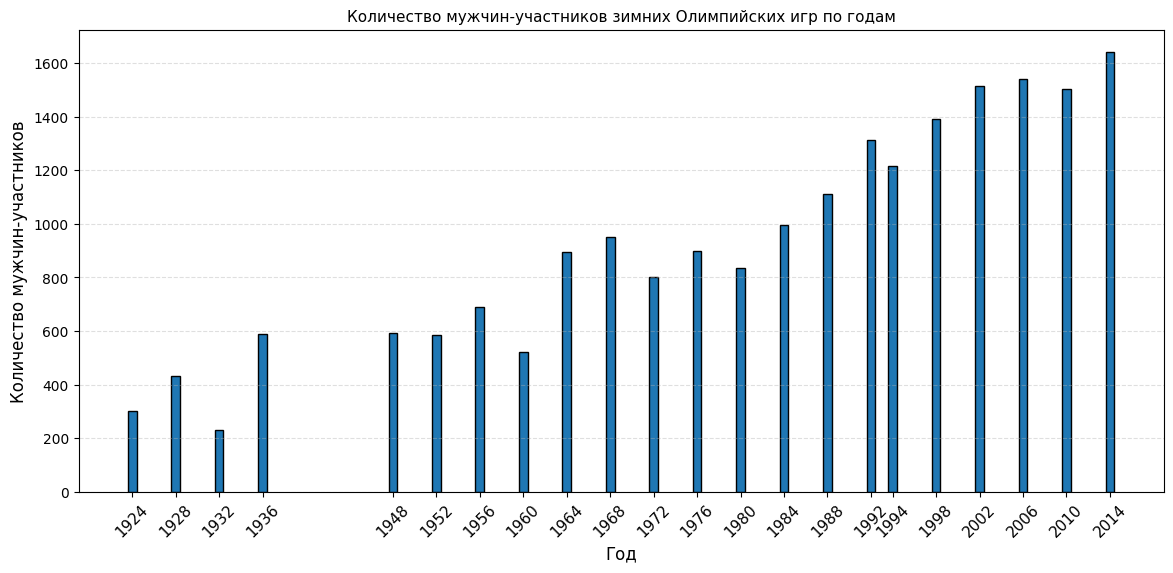

,Year,male_participants
0,1924,300
1,1928,433
2,1932,231
3,1936,588
4,1948,591


In [6]:
# 1 балл (сумма 5)
# Построить столбцовую гистограмму количества МУЖЧИН, участвовавших в зимних олимпиадах, по годам.
# Важно: один спортсмен может участвовать в нескольких дисциплинах в один год,
# поэтому считаем уникальных спортсменов по ID, а не количество строк.

male_participants = (
    olimpic[olimpic['Sex'] == 'M']
    .groupby('Year')['ID']
    .nunique()
    .reset_index(name='male_participants')
)

plt.figure(figsize=(14, 6))
plt.bar(male_participants['Year'], male_participants['male_participants'], edgecolor='black')
plt.title('Количество мужчин-участников зимних Олимпийских игр по годам', fontsize=11)
plt.xlabel('Год', fontsize=12)
plt.ylabel('Количество мужчин-участников', fontsize=12)
plt.xticks(male_participants['Year'], rotation=45, fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

male_participants.head()

In [7]:
# Посмотрим общую информацию по зимним Олимпиадам.

olimpic.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48564 entries, 4 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      48564 non-null  int64  
 1   Name    48564 non-null  object 
 2   Sex     48564 non-null  object 
 3   Age     48279 non-null  float64
 4   Height  40250 non-null  float64
 5   Weight  39543 non-null  float64
 6   Team    48564 non-null  object 
 7   NOC     48564 non-null  object 
 8   Games   48564 non-null  object 
 9   Year    48564 non-null  int64  
 10  Season  48564 non-null  object 
 11  City    48564 non-null  object 
 12  Sport   48564 non-null  object 
 13  Event   48564 non-null  object 
 14  Medal   5695 non-null   object 
dtypes: float64(3), int64(2), object(10)
memory usage: 5.9+ MB


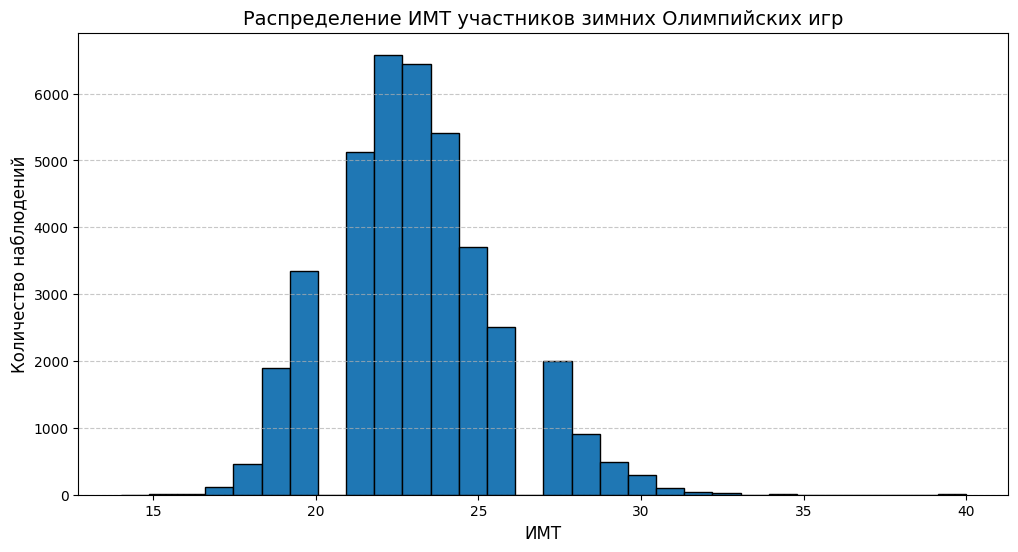

,Name,Height,Weight,BMI
4,Christine Jacoba Aaftink,185.0,82.0,24
5,Christine Jacoba Aaftink,185.0,82.0,24
6,Christine Jacoba Aaftink,185.0,82.0,24
7,Christine Jacoba Aaftink,185.0,82.0,24
8,Christine Jacoba Aaftink,185.0,82.0,24


In [8]:
# 1 балл (сумма 6)
# Построить распределение ИМТ (вес / (рост / 100)^2) для всех участников зимних олимпиад.
# ИМТ округляем до целых.

olimpic_bmi = olimpic.dropna(subset=['Height', 'Weight']).copy()

olimpic_bmi['BMI'] = (
    olimpic_bmi['Weight'] / ((olimpic_bmi['Height'] / 100) ** 2)
).round().astype(int)

plt.figure(figsize=(12, 6))
plt.hist(olimpic_bmi['BMI'], bins=30, edgecolor='black')
plt.title('Распределение ИМТ участников зимних Олимпийских игр', fontsize=14)
plt.xlabel('ИМТ', fontsize=12)
plt.ylabel('Количество наблюдений', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

olimpic_bmi[['Name', 'Height', 'Weight', 'BMI']].head()

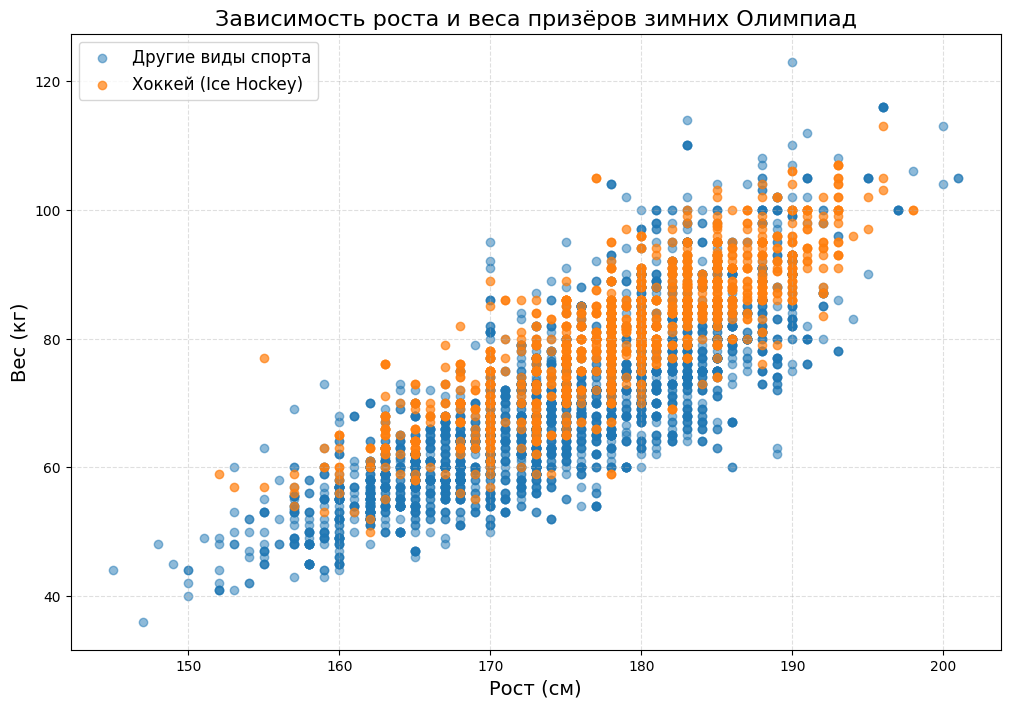

In [9]:
# 1 балл (сумма 7) 
# Визуализировать зависимость роста (ось X) и веса (ось Y)
# для всех ЧЕМПИОНОВ/ПРИЗЁРОВ зимних олимпиад, выделив точки для хоккея (`Ice Hockey`).
# Берём только строки, где есть медаль, рост и вес.

winter_medalists_hw = olimpic[
    olimpic['Medal'].notna() & 
    olimpic['Height'].notna() & 
    olimpic['Weight'].notna()
].copy()

hockey = winter_medalists_hw[winter_medalists_hw['Sport'] == 'Ice Hockey']
others = winter_medalists_hw[winter_medalists_hw['Sport'] != 'Ice Hockey']

plt.figure(figsize=(12, 8))

plt.scatter(
    others['Height'], 
    others['Weight'], 
    alpha=0.5, 
    label='Другие виды спорта'
)

plt.scatter(
    hockey['Height'], 
    hockey['Weight'], 
    alpha=0.7, 
    label='Хоккей (Ice Hockey)'
)

plt.title('Зависимость роста и веса призёров зимних Олимпиад', fontsize=16)
plt.xlabel('Рост (см)', fontsize=14)
plt.ylabel('Вес (кг)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(linestyle='--', alpha=0.4)
plt.show()

In [10]:
# 1 балл (сумма 8) 
# Создать отдельную таблицу для летних олимпийских игр с 1990 по 2010,
# в которой перекодировать медали: 'Gold': 5, 'Silver': 2, 'Bronze': 1.
# Для строк без медали ставим 0 баллов.

summer_1990_2010 = olimpic_all[
    (olimpic_all['Season'] == 'Summer') &
    (olimpic_all['Year'].between(1990, 2010))
].copy()

summer_1990_2010 = summer_1990_2010.merge(region, on='NOC', how='left')

medal_score = {'Gold': 5, 'Silver': 2, 'Bronze': 1}
summer_1990_2010['Medal_score'] = summer_1990_2010['Medal'].map(medal_score).fillna(0).astype(int)

summer_1990_2010.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes,Medal_score
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,China,NaN,0
1,12,Jyri Tapani Aalto,M,31.0,172.0,70.0,Finland,FIN,2000 Summer,2000,Summer,Sydney,Badminton,Badminton Men's Singles,NaN,Finland,NaN,0
2,13,Minna Maarit Aalto,F,30.0,159.0,55.5,Finland,FIN,1996 Summer,1996,Summer,Atlanta,Sailing,Sailing Women's Windsurfer,NaN,Finland,NaN,0
3,13,Minna Maarit Aalto,F,34.0,159.0,55.5,Finland,FIN,2000 Summer,2000,Summer,Sydney,Sailing,Sailing Women's Windsurfer,NaN,Finland,NaN,0
4,18,Timo Antero Aaltonen,M,31.0,189.0,130.0,Finland,FIN,2000 Summer,2000,Summer,Sydney,Athletics,Athletics Men's Shot Put,NaN,Finland,NaN,0


In [11]:
# 1 балл (сумма 9)
# Найти СПИСОК 5 команд (region), набравших суммарно больше всех баллов в медальном зачёте.

top_5_regions = (
    summer_1990_2010
    .groupby('region')['Medal_score']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

top_5_regions

region
USA          4137
Russia       2258
Germany      1812
Australia    1653
China        1580
Name: Medal_score, dtype: int64

In [12]:
# 1 балл (сумма 10)
# Найти, в каком году (индекс) и для каждой страны из списка (колонки) набрано медальных баллов.
# Используем список стран из прошлого задания.

top_5_region_names = top_5_regions.index.tolist()

points_by_year_region = (
    summer_1990_2010[summer_1990_2010['region'].isin(top_5_region_names)]
    .pivot_table(
        index='Year',
        columns='region',
        values='Medal_score',
        aggfunc='sum',
        fill_value=0
    )
    .reindex(columns=top_5_region_names)
    .astype(int)
)

points_by_year_region

region,USA,Russia,Germany,Australia,China
Year,,,,,
1992,630,649,579,140,199
1996,943,304,327,276,257
2000,823,518,265,492,258
2004,806,427,358,430,333
2008,935,360,283,315,533
